# FX and crypto: 24/7 data without an exchange session

Equity tooling leans on the session: the exchange defines "the day", the
open, the close. FX and crypto have none of that — EURUSD trades around the
clock with a weekend halt, BTC never stops, and "daily close" is a desk
*convention* (NY 5pm? Tokyo cut? UTC midnight?). This recipe shows the
h5i-db toolkit for that world: `time_bucket` with IANA timezone arguments
for session views, rows-based windows for rolling 24h vol, and `gapfill`
for regular grids across quiet periods.

**Honesty about the data**: the synthetic tick generator emits uniform
arrivals — it has no Tokyo/London/NY liquidity clock and no weekend halt.
We model the FX weekend explicitly (removing Fri 21:00 → Sun 21:00 UTC
ticks for the FX pairs, keeping BTC trading through it), and we flag below
where real data would show structure this data cannot.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("prod_fx"), create=True)

# 96 hours starting Friday 2026-06-05 00:00 UTC -> covers a full weekend.
raw = cu.make_fx_ticks(pairs=["EURUSD", "USDJPY", "BTCUSD"], hours=96, start="2026-06-05").to_pandas()

wk_open = pd.Timestamp("2026-06-05 21:00", tz="UTC")   # Fri 5pm ET
wk_close = pd.Timestamp("2026-06-07 21:00", tz="UTC")  # Sun 5pm ET
is_weekend = (raw["ts"] >= wk_open) & (raw["ts"] < wk_close)
ticks_df = raw[~(is_weekend & (raw["pair"] != "BTCUSD"))].reset_index(drop=True)
print(f"{len(raw):,} generated ticks -> {len(ticks_df):,} after removing the FX weekend")

864,000 generated ticks -> 575,395 after removing the FX weekend


## 1. Store the ticks

One `ticks` table for all three instruments. The FX weekend now shows up as
a hole in the per-day counts — while BTC prints straight through it, which
is exactly the asymmetry a multi-asset book has to live with.

In [2]:
schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("pair", pa.string()),
        pa.field("bid", pa.float64()),
        pa.field("ask", pa.float64()),
    ]
)
db.create_table("ticks", schema, time_column="ts", sort_key=["ts", "pair"])
db.append("ticks", pa.Table.from_pandas(ticks_df, schema=schema, preserve_index=False),
          note="4 days of FX/crypto ticks, FX weekend removed")

db.sql(
    """
    SELECT time_bucket('1d', ts) AS day_utc, pair, count(*) AS ticks
    FROM ticks GROUP BY day_utc, pair ORDER BY day_utc, pair
    """
).to_pandas().pivot(index="day_utc", columns="pair", values="ticks")

pair,BTCUSD,EURUSD,USDJPY
day_utc,,,
2026-06-05 00:00:00+00:00,72361.0,62877.0,62682.0
2026-06-06 00:00:00+00:00,71820.0,NaN,NaN
2026-06-07 00:00:00+00:00,71995.0,8956.0,8987.0
2026-06-08 00:00:00+00:00,71824.0,71794.0,72099.0


## 2. What is "a day"? Three answers from the same ticks

`time_bucket('1d', ts, tz)` aligns day boundaries to *local midnight* in any
IANA timezone — DST handled for you. The same tick stream yields different
daily closes under UTC, Tokyo, and New York conventions, because each cuts
the 24/7 flow at a different instant. (The common FX "NY 5pm" cut is local
17:00 rather than midnight — `time_bucket`'s optional origin argument can
shift the boundary if you need that exact convention.)

In [3]:
def daily_close(tz_expr: str, label: str) -> pd.DataFrame:
    out = db.sql(
        f"""
        SELECT time_bucket('1d', ts{tz_expr}) AS bucket,
               last_value((bid + ask) / 2 ORDER BY ts) AS close
        FROM ticks WHERE pair = 'EURUSD'
        GROUP BY bucket ORDER BY bucket
        """
    ).to_pandas()
    out[label + "_boundary_utc"] = out["bucket"].dt.strftime("%m-%d %H:%M")
    return out.rename(columns={"close": label})[[label + "_boundary_utc", label]]

utc = daily_close("", "close_utc")
tokyo = daily_close(", 'Asia/Tokyo'", "close_tokyo")
ny = daily_close(", 'America/New_York'", "close_ny")
pd.concat([utc, tokyo, ny], axis=1).round(5)

,close_utc_boundary_utc,close_utc,close_tokyo_boundary_utc,close_tokyo,close_ny_boundary_utc,close_ny
0,06-05 00:00,1.09531,06-04 15:00,1.09472,06-04 04:00,1.08267
1,06-07 00:00,1.10249,06-05 15:00,1.09531,06-05 04:00,1.09531
2,06-08 00:00,1.12921,06-07 15:00,1.10696,06-07 04:00,1.10811
3,NaN,NaN,06-08 15:00,1.12921,06-08 04:00,1.12921


Each convention's day starts at a different UTC instant (00:00, 15:00 —
Tokyo midnight, 04:00 — NY midnight EDT), so the "same day" close differs
across columns. On a real desk this is not pedantry: daily P&L, VaR windows
and carry accrual all inherit whichever cut you pick.

## 3. Hourly bars, stored — then rolling 24h realized vol

We persist hourly mid bars to their own table: derived tables are cheap in
h5i-db (one commit), and downstream queries — rolling windows, gapfill —
want a *stored* regular series to operate on. The rolling 24h vol is a
rows-based window (`ROWS BETWEEN 23 PRECEDING`), the natural frame on 24/7
data where every hour exists. One caveat from our FX weekend: missing hours
simply aren't rows, so the window silently spans the gap — Monday's first
bars mix Friday hours into "the last 24h". A regular grid (section 5) is
the fix when that matters.

In [4]:
bars = db.sql(
    """
    SELECT time_bucket('1h', ts) AS hr, pair,
           last_value((bid + ask) / 2 ORDER BY ts) AS mid_close,
           avg(ask - bid) AS avg_spread,
           count(*) AS ticks
    FROM ticks GROUP BY hr, pair ORDER BY hr, pair
    """
).to_arrow().rename_columns(["ts", "pair", "mid_close", "avg_spread", "ticks"])

bars_schema = pa.schema(
    [pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False)]
    + [bars.schema.field(i) for i in range(1, bars.num_columns)]
)
db.create_table("bars_1h", bars_schema, time_column="ts", sort_key=["ts", "pair"])
db.append("bars_1h", bars.cast(bars_schema), note="hourly mid bars")

rv = db.sql(
    """
    WITH r AS (
        SELECT ts, pair,
               ln(mid_close / lag(mid_close) OVER (PARTITION BY pair ORDER BY ts)) AS lr
        FROM bars_1h
    )
    SELECT ts, pair,
           sqrt(sum(lr * lr) OVER (PARTITION BY pair ORDER BY ts
                                   ROWS BETWEEN 23 PRECEDING AND CURRENT ROW) * 365.0) AS rv_ann
    FROM r ORDER BY ts, pair
    """
).to_pandas().dropna()
rv.tail(3)

,ts,pair,rv_ann
189,2026-06-08 23:00:00+00:00,BTCUSD,0.271188
190,2026-06-08 23:00:00+00:00,EURUSD,0.286058
191,2026-06-08 23:00:00+00:00,USDJPY,0.276358


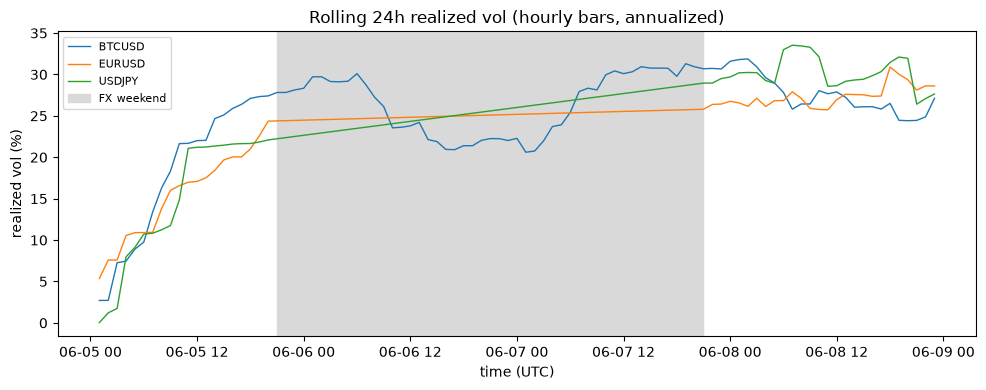

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
for pair, g in rv.groupby("pair"):
    ax.plot(g["ts"], 100 * g["rv_ann"], lw=1.0, label=pair)
ax.axvspan(wk_open, wk_close, color="0.85", zorder=0, label="FX weekend")
ax.set_title("Rolling 24h realized vol (hourly bars, annualized)")
ax.set_xlabel("time (UTC)")
ax.set_ylabel("realized vol (%)")
ax.legend(fontsize=8)
fig.tight_layout()

## 4. The liquidity clock — method on synthetic, structure on real data

The 24/7 week still has rhythm: Tokyo morning, the London/NY overlap
(roughly 12:00–16:00 UTC) where FX spreads are tightest, the post-NY lull.
The query is a bucket-by-hour-of-day over ticks and spreads; converting the
hour to a trading center's local time is a pandas `tz_convert` away.
**Expect the lines below to be flat**: uniform synthetic arrivals have no
clock. On real feed data this exact query draws the U-shapes and overlap
humps — the method, not this picture, is the takeaway.

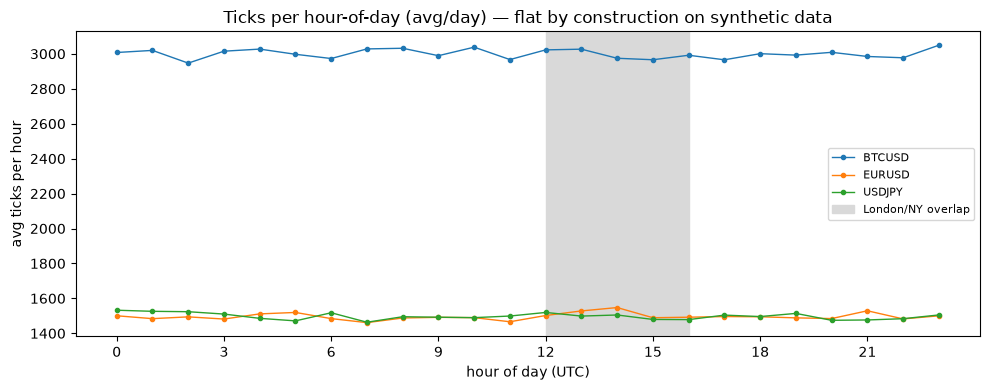

In [6]:
clock = db.sql(
    """
    SELECT extract(hour FROM ts) AS hour_utc, pair,
           count(*) AS ticks, avg(ask - bid) AS avg_spread
    FROM ticks GROUP BY hour_utc, pair ORDER BY hour_utc, pair
    """
).to_pandas()

fig, ax = plt.subplots(figsize=(10, 4))
for pair, g in clock.groupby("pair"):
    ax.plot(g["hour_utc"], g["ticks"] / 4.0, lw=1.0, marker="o", ms=3, label=pair)
ax.axvspan(12, 16, color="0.85", zorder=0, label="London/NY overlap")
ax.set_title("Ticks per hour-of-day (avg/day) — flat by construction on synthetic data")
ax.set_xlabel("hour of day (UTC)")
ax.set_ylabel("avg ticks per hour")
ax.set_xticks(range(0, 24, 3))
ax.legend(fontsize=8)
fig.tight_layout()

## 5. Regular grids with `gapfill` — and the phantom-return trap

`gapfill(table, time_col, step, mode)` samples a *stored* table onto a
regular grid. Two things to internalize:

- **step is in raw time units** — microseconds for `timestamp[us]` columns:
  `1_000_000` is a 1-second grid, `60_000_000` one minute. Generated grids
  are capped at 1M rows, so pick the step to fit the span.
- gapfill is a plain grid sampler with **no per-key grouping**: on a
  multi-instrument table, `locf` would carry *whichever pair last ticked*
  forward. Always gapfill a single-series table — so we store the EURUSD
  ticks on their own first.
- the `'null'` mode only emits a value where an observation coincides with
  a grid instant — on irregular ticks that is essentially never, so use
  `'locf'` (or `'interpolate'`) for sampling, and plain `time_bucket` bars
  when you want "only minutes that actually traded".

In [7]:
eur = ticks_df[ticks_df["pair"] == "EURUSD"]
db.create_table("eur_ticks", schema, time_column="ts", sort_key=["ts", "pair"])
db.append("eur_ticks", pa.Table.from_pandas(eur, schema=schema, preserve_index=False),
          note="EURUSD only, for gapfill")

# A research-grade 1-second grid: step = 1_000_000 us.
n_1s = db.sql("SELECT count(*) AS n FROM gapfill('eur_ticks', 'ts', 1000000, 'locf')").to_pandas()["n"][0]
print(f"1s locf grid over 96h: {n_1s:,} rows (cap is 1M — a 1s grid fits ~11 days)")

# A 1-minute locf grid, plus honest 1m bars (only minutes that actually traded):
grid_locf = db.sql("SELECT ts, bid, ask FROM gapfill('eur_ticks', 'ts', 60000000, 'locf')").to_pandas()
grid_locf["mid"] = (grid_locf["bid"] + grid_locf["ask"]) / 2
bars_1m = db.sql(
    """
    SELECT time_bucket('1m', ts) AS minute, last_value((bid + ask) / 2 ORDER BY ts) AS mid
    FROM eur_ticks GROUP BY minute ORDER BY minute
    """
).to_pandas()
print(f"1m locf grid: {len(grid_locf):,} rows; traded minutes: {len(bars_1m):,}; "
      f"fabricated by locf: {len(grid_locf) - len(bars_1m):,}")

1s locf grid over 96h: 345,599 rows (cap is 1M — a 1s grid fits ~11 days)
1m locf grid: 5,760 rows; traded minutes: 2,880; fabricated by locf: 2,880


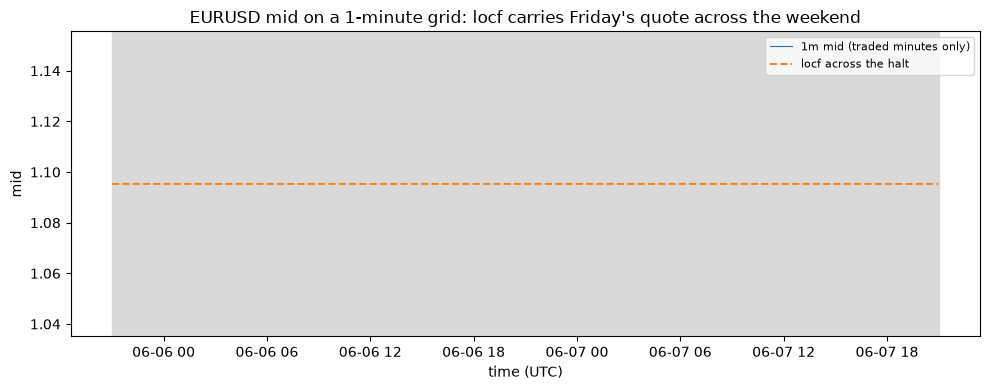

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_bars = bars_1m.set_index("minute")["mid"].reindex(grid_locf["ts"])  # NaN = untraded minute
ax.plot(grid_locf["ts"], plot_bars.values, lw=0.8, label="1m mid (traded minutes only)")
wk = grid_locf[(grid_locf["ts"] >= wk_open) & (grid_locf["ts"] < wk_close)]
ax.plot(wk["ts"], wk["mid"], lw=1.4, ls="--", label="locf across the halt")
ax.axvspan(wk_open, wk_close, color="0.85", zorder=0)
ax.set_title("EURUSD mid on a 1-minute grid: locf carries Friday's quote across the weekend")
ax.set_xlabel("time (UTC)")
ax.set_ylabel("mid")
ax.legend(fontsize=8)
fig.tight_layout()

The dashed segment is a *fabricated* flat line — that is what `locf` means.
It is the right choice for marking a book (the last quote **is** your best
knowledge), and the wrong input for return statistics: 2,880 zero returns
depress measured vol, and the whole weekend move lands as a single fake
1-minute print at the reopen (modest in this draw; after a volatile weekend
it is your biggest "1-minute" return by far).

In [9]:
ret_locf = np.log(grid_locf["mid"]).diff().dropna()
ret_traded = np.log(bars_1m["mid"]).diff().dropna()  # untraded minutes never enter

ann = np.sqrt(365 * 24 * 60)
pd.DataFrame(
    {
        "series": ["locf grid", "traded minutes only"],
        "n_returns": [len(ret_locf), len(ret_traded)],
        "ann_vol_pct": [100 * ret_locf.std() * ann, 100 * ret_traded.std() * ann],
        "max_abs_1m_ret_bp": [1e4 * ret_locf.abs().max(), 1e4 * ret_traded.abs().max()],
    }
).round(2)

,series,n_returns,ann_vol_pct,max_abs_1m_ret_bp
0,locf grid,5759,18.64,33.95
1,traded minutes only,2879,26.46,35.86


The zero-return padding knocks a third off measured vol, and the weekend
gap is compressed into one synthetic minute. The traded-minutes series —
plain `time_bucket` bars, which only exist where ticks exist — is the
honest input for vol estimation.

## Takeaways

- On 24/7 data "the day" is a parameter, not a fact: `time_bucket('1d', ts,
  '<IANA tz>')` gives session-aligned days for any convention, DST included —
  same ticks, different daily closes.
- Rows-based windows (`ROWS BETWEEN 23 PRECEDING`) are the natural rolling
  frame on continuous data, but they span data *gaps* silently — know your
  halts.
- `gapfill` needs a stored, single-series table; its step is raw
  microseconds (`1_000_000` = 1s) with a 1M-row grid cap.
- `locf` is for marking, traded-minute bars are for measuring: carrying
  quotes across a halt fabricates zero returns (vol biased down) plus one
  phantom gap print (tails biased up).
- Synthetic ticks have no liquidity clock — the hour-of-day queries here are
  the method to run on your real feed, where Tokyo/London/NY structure will
  actually appear.

In [10]:
db.close()